In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as pyplot
import math

In [3]:
nx = ny = 256
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
Y, X = np.meshgrid(y, x)

In [4]:
R = np.sqrt(X*X + Y*Y)
Theta = np.atan2(Y, X)
unit_mask = (R <= 1)

R = R * unit_mask

In [6]:
def get_radial_series(n: int, m: int) -> tuple[list, list]:
    """
    Returns a list of coefficients and corresponding powers for the radial
    part of the Zernike polynomial of the given order.
    """
    m = abs(m)
    assert n >= m, f"Invalid Zernike order: {n = }, {m = }"
    assert (n - m) % 2 == 0, f"Invalid Zernike order: {n = }, {m = }"

    def sign(k: int) -> float:
        return 1 if k % 2 == 0 else -1

    def numer(k: int) -> float:
        return math.factorial(n - k)

    def denom(k: int) -> float:
        return math.factorial(k) * math.factorial( ((n+m)//2) - k ) * math.factorial( ((n-m)//2) - k )

    k_iter = range((n - m)//2 + 1)
    coefs = [sign(k) * numer(k) / denom(k) for k in k_iter]
    powers = [n - 2*k for k in k_iter]
    return coefs, powers

def get_radial_term(R: np.ndarray, n: int, m: int) -> np.ndarray:
    """
    Returns the radial part of the (n, m) Zernike polynomial.
    """
    coefs, powers = get_radial_series(n, m)
    coefs = np.asarray(coefs)
    powers = np.asarray(powers)
    return (coefs * np.power(R[..., None], powers)).sum(-1)



In [7]:
rho = get_radial_term(R, 3, -3)

In [8]:
rho_true = 3*R**3 - 2*R

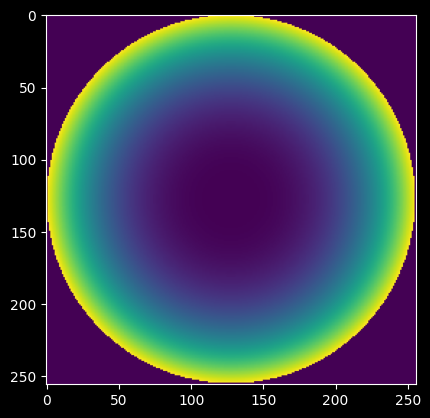

In [9]:
pyplot.imshow(rho)

In [10]:
def get_noll_index(n: int, m: int) -> int:
    if m > 0 and n % 4 < 2:
        mod_term = 0
    elif m < 0 and n % 4 >= 2:
        mod_term = 0
    elif m >= 0 and n % 4 >= 2:
        mod_term = 1
    else:
        mod_term = 1
    return n*(n + 1)//2 + abs(m) + mod_term


In [11]:
get_noll_index(1, -1)

3

In [12]:
from zernike_polynomials import generate_zernike_polynomial, get_radial_term, get_angular_term

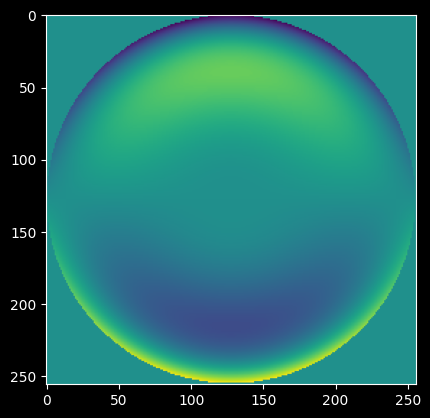

In [18]:
Z = generate_zernike_polynomial(R, Theta, 5, 3)
Z *= unit_mask
pyplot.imshow(Z)

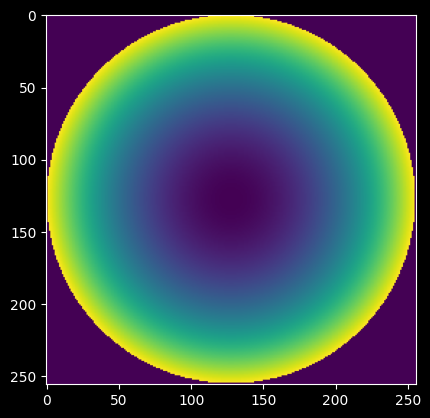

In [14]:
pyplot.imshow(get_radial_term(R, 2, 0))